1.Importing Libraries and Initializing Parameters

All necessary modules are imported and project-specific parameters are defined. Configuration settings such as image dimensions, batch size, learning rate, and processing device are established to maintain consistency throughout model development and evaluation.

In [4]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import mediapipe as mp
from tqdm import tqdm
import random
from torchvision.models.video import r3d_18
import matplotlib.pyplot as plt

real_path = "/kaggle/input/faceforensics/FF++/real"
fake_path = "/kaggle/input/faceforensics/FF++/fake"

frames_per_clip = 8
frame_size = 112
batch_size = 4
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


2.Video Data Processing and Feature Preparation

The video dataset is processed by extracting frames and identifying facial regions. Relevant features are generated and transformed into a format suitable for machine learning. This stage converts raw video data into structured inputs that can be utilized by the deepfake detection system.

In [ ]:


mp_face_detection = mp.solutions.face_detection

face_detector = mp_face_detection.FaceDetection(
    model_selection=1,          
    min_detection_confidence=0.5
)

preprocessed_dir = "./preprocessed_clips"
os.makedirs(preprocessed_dir, exist_ok=True)


class FaceMaskedVideoDataset(Dataset):
    def __init__(self, real_dir, fake_dir, frames_per_clip=8, frame_size=112, preprocess_dir="./preprocessed_clips"):
        self.frames_per_clip = frames_per_clip
        self.frame_size = frame_size
        self.preprocess_dir = preprocess_dir

        real_files = glob.glob(os.path.join(real_dir, "*.mp4"))
        fake_files = glob.glob(os.path.join(fake_dir, "*.mp4"))

        self.video_paths = real_files + fake_files
        self.labels = [0]*len(real_files) + [1]*len(fake_files)

        self.real_count = len(real_files)
        self.fake_count = len(fake_files)
        self.total_videos = len(self.video_paths)

        print(f"Total videos: {self.total_videos}, Real: {self.real_count}, Fake: {self.fake_count}")

        self.class_weights = [
            self.total_videos/(2*self.real_count),
            self.total_videos/(2*self.fake_count)
        ]

        self.preprocessed_data = []

        for idx in tqdm(range(len(self.video_paths)), desc="Preprocessing Videos", unit="video"):
            clip_path = os.path.join(preprocess_dir, f"{idx}.pt")

            if os.path.exists(clip_path):
                clip = torch.load(clip_path)
            else:
                clip, _ = self._load_video(idx)
                torch.save(clip, clip_path)

            self.preprocessed_data.append((clip, self.labels[idx]))


    def _load_video(self, idx):
        path = self.video_paths[idx]
        cap = cv2.VideoCapture(path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        skip = max(total_frames // self.frames_per_clip, 1)

        frames = []

        for i in range(self.frames_per_clip):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i*skip)
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.resize(frame, (self.frame_size, self.frame_size))
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            mask = np.zeros((self.frame_size, self.frame_size), dtype=np.float32)

            
            results = face_detector.process(frame_rgb)

            if results.detections:
                max_area = 0
                best_box = None

                for detection in results.detections:
                    bbox = detection.location_data.relative_bounding_box

                    x = int(bbox.xmin * self.frame_size)
                    y = int(bbox.ymin * self.frame_size)
                    w = int(bbox.width * self.frame_size)
                    h = int(bbox.height * self.frame_size)

                    area = w * h
                    if area > max_area:
                        max_area = area
                        best_box = (x, y, w, h)

                if best_box is not None:
                    x, y, w, h = best_box

                   
                    pad_w = int(0.3 * w)
                    pad_h = int(0.3 * h)

                    x1 = max(0, x - pad_w)
                    y1 = max(0, y - pad_h)
                    x2 = min(self.frame_size, x + w + pad_w)
                    y2 = min(self.frame_size, y + h + pad_h)

                    mask[y1:y2, x1:x2] = 1.0

           
            rgb_norm = frame_rgb / 255.0

            
            frame_4ch = np.concatenate([rgb_norm, mask[..., None]], axis=2)

            frames.append(frame_4ch)

        cap.release()

        if len(frames) < self.frames_per_clip:
            frames += [frames[-1]]*(self.frames_per_clip - len(frames))

        clip = np.stack(frames, axis=0).transpose(3,0,1,2)

        return torch.tensor(clip, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)


    def __len__(self):
        return len(self.preprocessed_data)

    def __getitem__(self, idx):
        return self.preprocessed_data[idx]

3.Dataset Organization and Sampling Strategy

The processed data is divided into training and testing subsets. Appropriate sampling methods are applied to maintain balanced class representation and improve the reliability of model learning and performance evaluation.

In [6]:
dataset = FaceMaskedVideoDataset(real_path, fake_path, frames_per_clip=frames_per_clip, frame_size=frame_size, preprocess_dir=preprocessed_dir)

sample_weights = [dataset.class_weights[label] for label in dataset.labels]
total_samples = len(dataset)
indices = torch.randperm(total_samples).tolist()
split_idx = int(0.8*total_samples)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

train_weights = [sample_weights[i] for i in train_idx]
train_sampler = WeightedRandomSampler(weights=train_weights, num_samples=len(train_idx), replacement=True)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler, num_workers=4, pin_memory=True)
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train videos: {len(train_idx)}, Test videos: {len(test_idx)}")



Total videos: 400, Real: 200, Fake: 200


Preprocessing Videos:   0%|          | 0/400 [00:00<?, ?video/s]/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Preprocessing Videos: 100%|██████████| 400/400 [19:53<00:00,  2.98s/video]

Train videos: 320, Test videos: 80


4.Preprocessed Data Verification

Sample outputs from the preprocessing pipeline are visualized to verify correctness. This step helps confirm that face extraction and feature generation have been performed successfully before initiating model training.

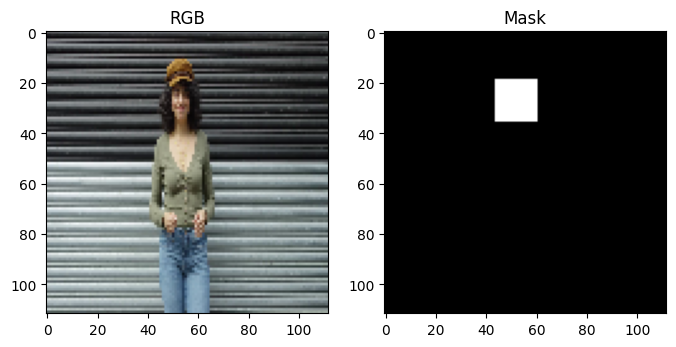

In [7]:
sample_clip, label = dataset[3]

import matplotlib.pyplot as plt

frame = sample_clip[:,0,:,:]   # first frame
rgb = frame[:3,:,:].permute(1,2,0).numpy()
mask = frame[3,:,:].numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.show()

5.Deep Learning Model Development

A deep learning architecture is constructed for detecting manipulated videos. The model is customized to learn spatial and temporal patterns from video sequences and classify them as genuine or deepfake content.

In [ ]:


model = r3d_18(pretrained=True)


original_conv = model.stem[0]

new_conv = nn.Conv3d(
    in_channels=4,
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=(original_conv.bias is not None)
)


with torch.no_grad():
    new_conv.weight[:, :3, :, :, :] = original_conv.weight
    new_conv.weight[:, 3:4, :, :, :] = original_conv.weight.mean(dim=1, keepdim=True)

model.stem[0] = new_conv



num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)





for param in model.parameters():
    param.requires_grad = False


for param in model.stem.parameters():
    param.requires_grad = True


for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True


for param in model.fc.parameters():
    param.requires_grad = True


model = model.to(device)

print("Model ready with 4-channel input")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth
100%|██████████| 127M/127M [00:00<00:00, 228MB/s]


Model ready with 4-channel input


6.Training Configuration and Optimization Setup

The training framework is established by defining the loss function, optimization algorithm, and other learning parameters. These settings guide the model toward minimizing prediction errors and improving classification performance.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()
num_epochs = 20  


<ipython-input-9-6e5590e622aa>:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


7.Model Training and Validation

The model is trained using the prepared dataset and validated at regular intervals. During this phase, the network learns meaningful patterns associated with authentic and manipulated videos while monitoring its generalization capability.

In [10]:
train_losses, train_accs, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} - Train", unit="batch")
    for clips, labels in train_bar:
        clips, labels = clips.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(clips)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size_current = labels.size(0)
        running_loss += loss.item()*batch_size_current
        preds = torch.argmax(outputs, dim=1)
        running_corrects += torch.sum(preds==labels).item()
        total_train += batch_size_current
        train_bar.set_postfix(loss=running_loss/total_train, acc=100.*running_corrects/total_train)

    train_losses.append(running_loss/total_train)
    train_accs.append(100.*running_corrects/total_train)

    # Validation
    model.eval()
    val_corrects = 0
    total_val = 0
    val_bar = tqdm(test_loader, desc=f"Epoch {epoch}/{num_epochs} - Validate", unit="batch")
    with torch.no_grad():
        for clips, labels in val_bar:
            clips, labels = clips.to(device), labels.to(device)
            outputs = model(clips)
            preds = torch.argmax(outputs, dim=1)
            val_corrects += torch.sum(preds==labels).item()
            total_val += labels.size(0)
            val_bar.set_postfix(acc=100.*val_corrects/total_val)

    val_acc = 100.*val_corrects/total_val
    val_accs.append(val_acc)
    print(f"Epoch {epoch} - Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Saved best model with val_acc={val_acc:.2f}%")


Epoch 1/20 - Train:   0%|          | 0/80 [00:00<?, ?batch/s]<ipython-input-10-0ff360debdb3>:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/20 - Validate: 100%|██████████| 100/100 [00:03<00:00, 31.24batch/s, acc=66.2]


Epoch 1 - Val Acc: 66.25%
Saved best model with val_acc=66.25%


Epoch 2/20 - Validate: 100%|██████████| 100/100 [00:03<00:00, 31.23batch/s, acc=74.2]


Epoch 2 - Val Acc: 74.25%
Saved best model with val_acc=74.25%


Epoch 3/20 - Validate: 100%|██████████| 100/100 [00:03<00:00, 31.51batch/s, acc=76]


...

Epoch 18 - Val Acc: 85.25%


Epoch 19/20 - Validate: 100%|██████████| 100/100 [00:03<00:00, 31.45batch/s, acc=88.8]


Epoch 19 - Val Acc: 88.75%
Saved best model with val_acc=88.75%


Epoch 20/20 - Validate: 100%|██████████| 100/100 [00:03<00:00, 31.47batch/s, acc=88.5]

Epoch 20 - Val Acc: 88.50%


8.Trained Model Preservation

After successful training, the learned model parameters are stored for future use. Saving the model enables efficient deployment, testing, and further experimentation without repeating the complete training process.

In [11]:
torch.save(model.state_dict(), "final_model.pth")
print("Saved final model as 'final_model.pth'")


Saved final model as 'final_model.pth'


9.Performance Assessment and Testing

The trained model is evaluated using unseen data to measure its effectiveness. Performance metrics are analyzed to determine the model's capability in accurately distinguishing real videos from deepfake videos.

In [12]:
model.eval()
test_corrects = 0
total_test = 0
for clips, labels in tqdm(test_loader, desc="Testing", unit="batch"):
    clips, labels = clips.to(device), labels.to(device)
    outputs = model(clips)
    preds = torch.argmax(outputs, dim=1)
    test_corrects += torch.sum(preds==labels).item()
    total_test += labels.size(0)

test_acc = 100.*test_corrects/total_test
print(f"Test Accuracy: {test_acc:.2f}%")


Testing: 100%|██████████| 100/100 [00:03<00:00, 32.51batch/s]

Test Accuracy: 88.50%


10.Visualization of Experimental Results

Graphs and performance plots are generated to illustrate training progress and evaluation outcomes. These visual representations provide insights into model behavior, convergence trends, and overall effectiveness of the proposed system.

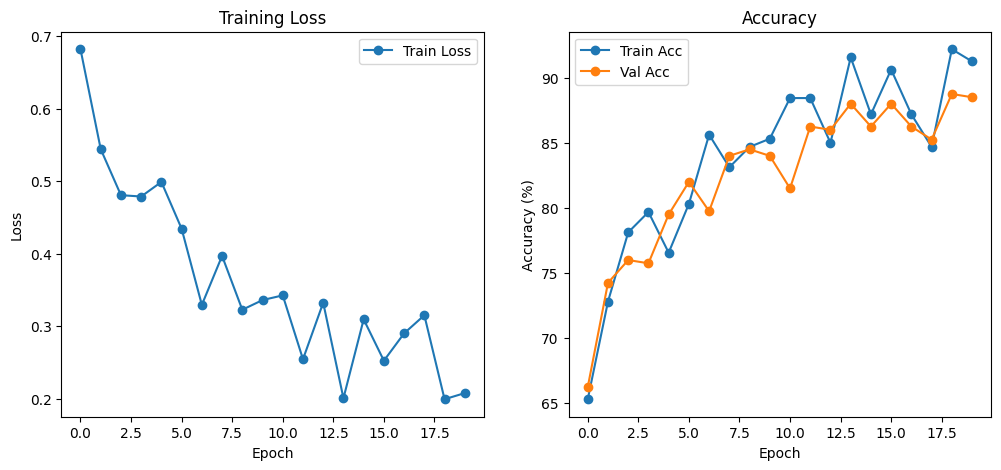

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc", marker='o')
plt.plot(val_accs, label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.legend()
plt.show()
